# DATASCI 503, Group Work 11: Neural Networks and Regularization

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. **During lab, feel free to flag down your GSI to ask questions at any point!**

## PLEASE USE RANDOM STATE 42 FOR THIS ASSIGNMENT

## **NOTE**: This assignment requires training multiple neural networks for several epochs. Please ensure you provide yourself with ample time to run the full notebook from start to finish and generate all outputs before submission.

## Part 1: PyTorch Fundamentals

In [1]:
import torch
from matplotlib import pyplot as plt

---

**Problem 1:** Gradient Descent with Autograd

Consider the simple regression problem given $X=(x_1,\dots,x_n)$ as a vector of length $n$ and targets $Y=(y_1,\dots,y_n)$. Use gradient descent to minimize the Mean Squared Error loss:

$$f(w) = \frac{1}{n}\sum_i (y_i - w_0 - w_1 x_i)^2$$

Write a function `mse_gd` that takes as input:
- `features`: Input feature tensor
- `targets`: Target tensor
- `eta`: Step size (learning rate), default 0.1
- `max_iter`: Maximum number of iterations, default 1000

The function should:
1. Randomly initialize weights from a standard normal distribution using `torch.randn`
2. Use PyTorch's autograd to compute gradients
3. Update weights using gradient descent

Return the learned weights `w` as a tensor of shape `(2,)` where `w[0]` is the intercept and `w[1]` is the slope.

In [ ]:
def mse_gd(features, targets, eta=1e-1, max_iter=1000):
    """MSE loss minimization with gradient descent.

    Args:
        features: A tensor of shape (n_samples,) or (n_samples, n_features).
        targets: A tensor of shape (n_samples,).
        eta: Learning rate.
        max_iter: Maximum number of iterations.

    Returns:
        A tuple of (weights, losses), where weights is a tensor of shape (2,)
        for [intercept, slope]
    """
    x = features.view(-1, 1) # Ensure features is a 2D tensor
    X = torch.cat([torch.ones_like(x), x], dim=1) # Add a column of ones for the intercept term

    weights = torch.randn(2, requires_grad=True) # Initialize weights randomly

    # Perform gradient descent
    for _ in range(max_iter):
        predictions = X @ weights
        loss = torch.mean((predictions - targets) ** 2)

        loss.backward() # Compute gradients
        with torch.no_grad():
            weights -= eta * weights.grad # update weights
            weights.grad.zero_() # Reset gradients for the next iteration

    return weights

In [8]:
# Test assertions
torch.manual_seed(10)
X_test_gd = torch.rand(60)
y_test_gd = 2.0 - 1.4 * X_test_gd + torch.randn(60) * 0.3

weights_result = mse_gd(X_test_gd, y_test_gd)
weights_np = weights_result.detach().numpy()

assert weights_result.shape == (2,), f"Expected shape (2,), got {weights_result.shape}"
assert abs(weights_np[0] - 2.0) < 0.3, f"Intercept should be close to 2.0, got {weights_np[0]:.4f}"
assert abs(weights_np[1] - (-1.4)) < 0.3, f"Slope should be close to -1.4, got {weights_np[1]:.4f}"
print("All tests passed!")


All tests passed!


Run the next cell to check your implementation visually.

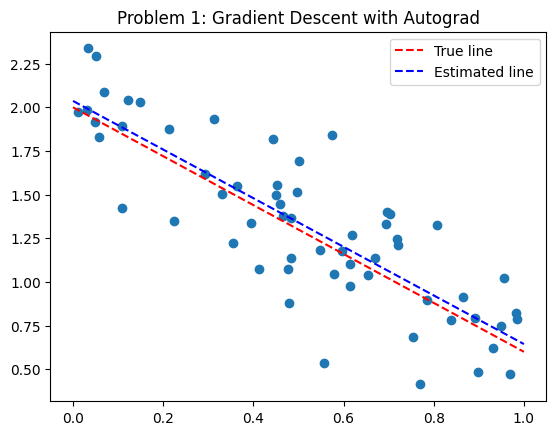

In [9]:
# NO NEED TO EDIT THIS CELL
torch.manual_seed(10)
X = torch.rand(60)
y = 2.0 - 1.4 * X + torch.randn(60) * 0.3

w = mse_gd(X, y)
w = w.detach().numpy()  # need to detach tensors that require grad before calling numpy

plt.scatter(X, y)
plt.plot([0, 1], [2, 0.6], color="red", linestyle="dashed", label="True line")
plt.plot([0, 1], [w[0], w[0] + w[1]], color="blue", linestyle="dashed", label="Estimated line")
plt.legend()
plt.title("Problem 1: Gradient Descent with Autograd")
plt.show()

## Part 2: Fashion MNIST — Overfitting, Underfitting, and Regularization

In this section, we will apply deep learning to the Fashion MNIST dataset.
The Fashion MNIST dataset is a popular benchmark dataset for machine learning and computer vision, often used as a drop-in replacement for the original MNIST dataset of handwritten digits. Fashion MNIST is composed of 70,000 grayscale images in total, each having a resolution of 28x28 pixels. The dataset is divided into 60,000 training images and 10,000 testing images. Each image depicts an item of clothing or accessory, categorized into one of ten classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot.

For more details on Fashion MNIST, see the [official documentation](https://github.com/zalandoresearch/fashion-mnist).

PyTorch, via torchvision, makes it easy to load the Fashion MNIST dataset. Run the cell below to download the data and create training and validation dataloaders.

In [10]:
import numpy as np
import seaborn as sns
import torch
import torchvision
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# Set random seed for reproducibility
torch.manual_seed(42)

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()])

# Download the full training dataset
full_train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

# Define the sizes
train_size = int(0.7 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset into training and validation sets
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Download the test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# Loss function to use throughout
criterion = nn.CrossEntropyLoss()

100%|██████████| 26.4M/26.4M [00:13<00:00, 1.97MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.98MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.93MB/s]


We provide you with the following function for training your model.

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs=50):
    """Train a model and return training and validation losses.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        optimizer: PyTorch optimizer
        num_epochs: Number of training epochs

    Returns:
        Tuple of (training_losses, val_losses) lists
    """
    val_losses = []
    training_losses = []

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        train_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward() # Compute gradients
            optimizer.step() # Update weights; accomodates general class of optimizers

            train_loss += loss.item()

        train_loss /= len(train_loader)
        training_losses.append(train_loss)

        model.eval() # Set model to evaluation mode
        val_loss = 0
        with torch.no_grad(): # Disable gradient computation for validation
            for batch_x, batch_y in val_loader:
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        val_losses.append(val_loss)
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, "
                f"Training Loss: {train_loss:.4f}, "
                f"Validation Loss: {val_loss:.4f}"
            )

    return training_losses, val_losses

---

**Problem 2:** Demonstrating Underfitting

Create a model that underfits the data for at least 50 epochs. Using the `train_model` function above, demonstrate that the training loss drops steadily while the validation loss remains similar (within 0.05) to the training loss throughout training. This behavior indicates that the model lacks sufficient capacity to fully capture the patterns in the data.

**Hint:** Use a very small hidden layer (e.g., 2 neurons) to severely limit model capacity.

Store the training and validation losses in `underfit_training_losses` and `underfit_validation_losses`.

In [ ]:
# Define an underfitting model
    # nn.Sequential orders layers in a linear sequence 
torch.manual_seed(42) # Set random seed for reproducibility in random weight initialization
model_underfit = nn.Sequential( 
    nn.Flatten(),
    # 28 x 28 input image size; 2 hidden units is too small for this task, leading to underfitting
    nn.Linear(28 * 28, 2), 
    # nonlinear activation function 
    nn.ReLU(),
    # Output layer with 10 classes for FashionMNIST
    nn.Linear(2, 10),
)

optimizer = optim.SGD(model_underfit.parameters(), lr=0.1)
underfit_training_losses, underfit_validation_losses = train_model(
    model_underfit, train_loader, val_loader, optimizer, num_epochs=50
)

Epoch 10/50, Training Loss: 1.4790, Validation Loss: 1.5051
Epoch 20/50, Training Loss: 1.4022, Validation Loss: 1.5810
Epoch 30/50, Training Loss: 1.3682, Validation Loss: 1.3693


KeyboardInterrupt: 

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(underfit_training_losses, label="Training Loss")
plt.plot(underfit_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 2: Underfitting")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# Check that training and validation losses are within 0.05 of each other for most epochs
loss_differences = np.abs(np.array(underfit_training_losses) - np.array(underfit_validation_losses))
proportion_close = np.mean(loss_differences < 0.05)
assert (
    proportion_close > 0.9
), f"Expected 90%+ of epochs to have losses within 0.05, got {proportion_close:.1%}"
assert (
    len(underfit_training_losses) == 50
), f"Expected 50 epochs, got {len(underfit_training_losses)}"
print("All tests passed!")



---

**Problem 3:** Demonstrating Overfitting

Now demonstrate overfitting with a larger model. During training, the training loss should drop steadily while the validation loss should drop initially and then begin increasing. This divergence between training and validation loss is the hallmark of overfitting.

**Hint:** Use a larger model with more hidden neurons (e.g., 128 neurons per layer).

Store the training and validation losses in `overfit_training_losses` and `overfit_validation_losses`.

In [ ]:
# Define an overfitting model
    # nn.Sequential orders layers in a linear sequence 
model_overfit = nn.Sequential( 
    nn.Flatten(),
    # 28 x 28 input image size; 128 hidden units is large enough for this task, leading to overfitting
    nn.Linear(28 * 28, 128), 
    # nonlinear activation function 
    nn.ReLU(),
    # Output layer with 10 classes for FashionMNIST
    nn.Linear(128, 10),
)

optimizer = optim.SGD(model_overfit.parameters(), lr=0.1)
overfit_training_losses, overfit_validation_losses = train_model(
    model_overfit, train_loader, val_loader, optimizer, num_epochs=50
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(overfit_training_losses, label="Training Loss")
plt.plot(overfit_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 3: Overfitting")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# Check for overfitting: training loss should be much lower than validation loss at end
final_gap = overfit_validation_losses[-1] - overfit_training_losses[-1]
assert final_gap > 0.1, f"Expected significant gap between losses, got {final_gap:.3f}"
# Check that validation loss increases in latter half of training
min_val_idx = np.argmin(overfit_validation_losses)
assert min_val_idx < 40, "Validation loss should reach minimum before epoch 40 for overfitting"
print("All tests passed!")



---

**Problem 4:** Early Stopping

Early stopping is a regularization technique that stops training when the validation loss begins to increase. It compares the new validation loss to the previous best validation loss and increments a counter every time the loss increases above the best previous value by a certain threshold (`min_delta`). If this counter reaches a given limit (called `patience`), the training stops.

Write a function `train_model_with_early_stopping` that modifies the training loop to implement early stopping. Your function should:
1. Track the best validation loss seen so far
2. Increment a counter when the validation loss does not improve by at least `min_delta`
3. Stop training when the counter reaches `patience`

Then, train a model with the same architecture as Problem 3 using early stopping.

Store the training and validation losses in `early_training_losses` and `early_validation_losses`.

In [ ]:
def train_model_with_early_stopping(
    model, train_loader, val_loader, optimizer, num_epochs=100, patience=5, min_delta=0.01
):
    """Train a model with early stopping.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        optimizer: PyTorch optimizer
        num_epochs: Maximum number of training epochs
        patience: Number of epochs to wait for improvement
        min_delta: Minimum improvement required to reset patience counter

    Returns:
        Tuple of (training_losses, validation_losses) lists
    """
    best_val_loss = float("inf")
    patience_counter = 0
    validation_losses = []
    training_losses = []

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        train_loss = 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        training_losses.append(train_loss)

        model.eval()  # Set model to evaluation mode
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        validation_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, "
                f"Training Loss: {train_loss:.4f}, "
                f"Validation Loss: {val_loss:.4f}"
            )

        # Check for improvement in validation loss
        if best_val_loss - val_loss > min_delta:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        # Stop training if no improvement for 'patience' epochs
        if patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}/{num_epochs}, "
                f"Training Loss: {train_loss:.4f}, "
                f"Validation Loss: {val_loss:.4f}"
            )
            break

    return training_losses, validation_losses

In [ ]:
torch.manual_seed(42)

model_early = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

optimizer = optim.SGD(model_early.parameters(), lr=0.1)
early_training_losses, early_validation_losses = train_model_with_early_stopping(
    model_early, train_loader, val_loader, optimizer
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(early_training_losses, label="Training Loss")
plt.plot(early_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Problem 4: Early Stopping (stopped at epoch {len(early_training_losses)})")
plt.legend()
plt.show()

In [ ]:
# Test assertions
import inspect

# Check that early stopping triggered before 50 epochs
assert (
    len(early_training_losses) < 50
), f"Expected early stopping before 50 epochs, ran {len(early_training_losses)}"
assert len(early_training_losses) == len(
    early_validation_losses
), "Training and validation loss lists should have same length"
print("All tests passed!")



---

**Problem 5:** Reduced Hidden Dimension

One way to reduce overfitting is to reduce the model capacity by using fewer hidden neurons. Try reducing the size of your model from Problem 3 to avoid overfitting.

Store the training and validation losses in `smaller_training_losses` and `smaller_validation_losses`.

In [ ]:
torch.manual_seed(42)

model_smaller = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 32),
    nn.ReLU(),
    nn.Linear(32, 10),
)

optimizer = optim.SGD(model_smaller.parameters(), lr=0.1)
smaller_training_losses, smaller_validation_losses = train_model(
    model_smaller, train_loader, val_loader, optimizer, num_epochs=50
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(smaller_training_losses, label="Training Loss")
plt.plot(smaller_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 5: Reduced Hidden Dimension")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# Smaller model should overfit less (smaller gap between train and val loss)
smaller_gap = smaller_validation_losses[-1] - smaller_training_losses[-1]
overfit_gap = overfit_validation_losses[-1] - overfit_training_losses[-1]
assert (
    smaller_gap < overfit_gap
), f"Expected smaller gap with reduced model, got {smaller_gap:.3f} vs {overfit_gap:.3f}"
assert len(smaller_training_losses) == 50, f"Expected 50 epochs, got {len(smaller_training_losses)}"
print("All tests passed!")



---

**Problem 6:** L2 Regularization

L2 regularization (also called weight decay) penalizes large weights by adding the squared magnitude of weights to the loss function. In PyTorch, this is implemented through the `weight_decay` parameter in the optimizer.

Use L2 regularization when training the model from Problem 3 to reduce overfitting.

**Hint:** Set `weight_decay=0.01` in the Adam optimizer.

Store the training and validation losses in `l2_training_losses` and `l2_validation_losses`.

In [ ]:
torch.manual_seed(42)

model_l2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

optimizer = optim.Adam(model_l2.parameters(), lr=0.1, weight_decay=0.01)
l2_training_losses, l2_validation_losses = train_model(
    model_l2, train_loader, val_loader, optimizer, num_epochs=50
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(l2_training_losses, label="Training Loss")
plt.plot(l2_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 6: L2 Regularization")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# L2 regularization should reduce overfitting (smaller gap between train and val)
l2_gap = l2_validation_losses[-1] - l2_training_losses[-1]
assert (
    l2_gap < overfit_gap
), f"Expected L2 to reduce overfitting gap, got {l2_gap:.3f} vs {overfit_gap:.3f}"
assert len(l2_training_losses) == 50, f"Expected 50 epochs, got {len(l2_training_losses)}"
print("All tests passed!")



---

**Problem 7:** Dropout Regularization

Dropout is a regularization technique that randomly sets a fraction of neurons to zero during training, which prevents co-adaptation of neurons and reduces overfitting.

Add dropout to the model from Problem 3 to reduce overfitting.

**Hint:** Use `nn.Dropout(p)` where `p` is the probability of setting a neuron to zero (e.g., `p=0.5` or higher).

Store the training and validation losses in `dropout_training_losses` and `dropout_validation_losses`.

In [ ]:
torch.manual_seed(42)

model_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(0.5), # Dropout layer with 50% dropout rate; after ReLU to avoid dropping out all activations
    nn.Linear(128, 10),
)

optimizer = optim.SGD(model_dropout.parameters(), lr=0.1)
dropout_training_losses, dropout_validation_losses = train_model(
    model_dropout, train_loader, val_loader, optimizer, num_epochs=50
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(dropout_training_losses, label="Training Loss")
plt.plot(dropout_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 7: Dropout Regularization")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# Dropout should reduce overfitting (smaller gap between train and val)
dropout_gap = dropout_validation_losses[-1] - dropout_training_losses[-1]
assert (
    dropout_gap < overfit_gap
), f"Expected dropout to reduce overfitting gap, got {dropout_gap:.3f} vs {overfit_gap:.3f}"
assert len(dropout_training_losses) == 50, f"Expected 50 epochs, got {len(dropout_training_losses)}"
print("All tests passed!")



---

**Problem 8:** Combining L2 and Dropout

Use both L2 regularization (weight decay) and dropout together to reduce overfitting.

Store the training and validation losses in `l2dropout_training_losses` and `l2dropout_validation_losses`.

In [ ]:
torch.manual_seed(42)

model_l2dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10),
)

optimizer = optim.Adam(model_l2dropout.parameters(), lr=0.1, weight_decay=0.01)
l2dropout_training_losses, l2dropout_validation_losses = train_model(
    model_l2dropout, train_loader, val_loader, optimizer, num_epochs=50
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(l2dropout_training_losses, label="Training Loss")
plt.plot(l2dropout_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 8: L2 + Dropout")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# Combined regularization should reduce overfitting
l2dropout_gap = l2dropout_validation_losses[-1] - l2dropout_training_losses[-1]
assert (
    l2dropout_gap < overfit_gap
), f"Expected combined regularization to reduce gap, got {l2dropout_gap:.3f}"
assert (
    len(l2dropout_training_losses) == 50
), f"Expected 50 epochs, got {len(l2dropout_training_losses)}"
print("All tests passed!")


---

**Problem 9:** Combining Dropout and Early Stopping

Use both dropout and early stopping together to reduce overfitting.

Store the training and validation losses in `dropoutearly_training_losses` and `dropoutearly_validation_losses`.

In [ ]:
torch.manual_seed(42)

model_dropoutearly = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10),
)

optimizer = optim.SGD(model_dropoutearly.parameters(), lr=0.1)
dropoutearly_training_losses, dropoutearly_validation_losses = train_model_with_early_stopping(
    model_dropoutearly, train_loader, val_loader, optimizer
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(dropoutearly_training_losses, label="Training Loss")
plt.plot(dropoutearly_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Problem 9: Dropout + Early Stopping (stopped at epoch {len(dropoutearly_training_losses)})")
plt.legend()
plt.show()

In [ ]:
# Test assertions
# Should stop before 50 epochs due to early stopping
assert (
    len(dropoutearly_training_losses) < 50
), f"Expected early stopping before 50 epochs, ran {len(dropoutearly_training_losses)}"
assert len(dropoutearly_training_losses) == len(
    dropoutearly_validation_losses
), "Training and validation loss lists should have same length"
print("All tests passed!")



---

**Problem 10:** Implicit Regularization

Some regularization occurs implicitly through training hyperparameters. In particular, larger learning rates and smaller batch sizes can act as implicit regularizers by adding noise to the gradient updates.

Modify the learning rate and/or batch size to reduce overfitting. You will need to create a new DataLoader with a different batch size.

**Note:** You should use the same model architecture as in Problem 3 (the overfitting model).

Store the training and validation losses in `implreg_training_losses` and `implreg_validation_losses`.

In [ ]:
torch.manual_seed(42)

train_loader_implreg = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_implreg = DataLoader(val_dataset, batch_size=1024, shuffle=False)

model_implreg = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

optimizer = optim.SGD(model_implreg.parameters(), lr=0.2)
implreg_training_losses, implreg_validation_losses = train_model(
    model_implreg, train_loader_implreg, val_loader_implreg, optimizer, num_epochs=50
)

In [ ]:
# NO NEED TO EDIT THIS CELL
plt.figure(figsize=(8, 5))
plt.plot(implreg_training_losses, label="Training Loss")
plt.plot(implreg_validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Problem 10: Implicit Regularization")
plt.legend()
plt.show()

In [ ]:
# Test assertions
assert len(implreg_training_losses) == 50, f"Expected 50 epochs, got {len(implreg_training_losses)}"
assert len(implreg_training_losses) == len(
    implreg_validation_losses
), "Training and validation loss lists should have same length"
print("All tests passed!")



---

**Problem 11:** Model Comparison and Analysis

Run the code below to print the validation and test loss for each model.

Then create a single figure with 3 subplots showing the confusion matrices for the three models with the best test loss. Use seaborn's `heatmap` function to visualize the confusion matrices.

Store the indices of the three best models in `best_indices` (as a NumPy array sorted by test loss, ascending).

In [ ]:
# NO NEED TO EDIT THIS CELL
# List of all models and their names
models = [
    model_underfit,
    model_overfit,
    model_early,
    model_smaller,
    model_l2,
    model_dropout,
    model_l2dropout,
    model_dropoutearly,
    model_implreg,
]
model_names = [
    "Underfit",
    "Overfit",
    "Early Stopping",
    "Smaller Model",
    "L2 Regularization",
    "Dropout",
    "L2 and Dropout",
    "Dropout and Early Stopping",
    "Implicit Regularization",
]


def get_loss(model, loader):
    """Compute average loss for a model on a data loader."""
    model.eval()
    loss = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            outputs = model(batch_x)
            batch_loss = criterion(outputs, batch_y)
            loss += batch_loss.item()
    return loss / len(loader)


# Print validation and test losses for all models
test_losses = []
for model, model_name in zip(models, model_names):
    val = get_loss(model, val_loader)
    test = get_loss(model, test_loader)
    test_losses.append(test)
    print(f"{model_name:>25}: validation={val:.4f} test={test:.4f}")

In [ ]:
# BEGIN SOLUTION
# Fashion MNIST class names for readable labels
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Get indices of three models with lowest test loss
best_indices = np.argsort(test_losses)[:3]

# Create confusion matrix subplots for the three best models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, model_index in zip(axes, best_indices):
    model = models[model_index]
    all_predictions = []
    all_targets = []

    model.eval()
    with torch.no_grad():
        # Iterate through test data and collect predictions and true labels
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            predictions = torch.argmax(outputs, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    cm = confusion_matrix(all_targets, all_predictions)

    sns.heatmap(
        cm,
        ax=axis,
        cmap="Blues",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
    )
    axis.set_title(model_names[model_index])
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")

plt.tight_layout()

In [ ]:
# Test assertions
# Verify that best_indices contains 3 models
assert len(best_indices) == 3, f"Expected 3 best models, got {len(best_indices)}"
# Verify that test_losses list has the right length
assert len(test_losses) == 9, f"Expected 9 test losses, got {len(test_losses)}"
print("All tests passed!")

